# Stable Diffusion Homework Fix

This notebook uses a **pure PyTorch latent-diffusion pipeline** adapted from the conditional pieces of `StableDiffusion2026.ipynb`.

Homework compliance:

- Dataset: `Food-101` from `torchvision`
- Images: RGB color food photographs
- Condition: numeric class labels (`0` to `9`) with a fixed label-to-class mapping
- Training: from scratch
- Frameworks: PyTorch + torchvision only
- Stable-diffusion style: train a small **VAE first**, then run **conditional diffusion in latent space**

To keep training practical, the notebook uses a **10-class balanced subset** of Food-101 instead of all 101 classes.

In [11]:
import math
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

In [13]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

IMAGE_SIZE = 64
LATENT_CHANNELS = 4
LATENT_SIZE = IMAGE_SIZE // 4
BATCH_SIZE = 64
AUTOENCODER_EPOCHS = 15
DIFFUSION_EPOCHS = 40
LR_AUTOENCODER = 2e-4
LR_DIFFUSION = 2e-4
KL_WEIGHT = 1e-4
SIGMA = 25.0
NUM_DIFFUSION_STEPS = 300
NUM_WORKERS = 2
MAX_SAMPLES_PER_CLASS = 500

SELECTED_FOOD_CLASSES = [
    "apple_pie",
    "baby_back_ribs",
    "hamburger",
    "caesar_salad",
    "cheesecake",
    "fried_rice",
    "ice_cream",
    "pizza",
    "steak",
    "sushi",
]
LABEL_TO_CLASS = {idx: name for idx, name in enumerate(SELECTED_FOOD_CLASSES)}
CLASS_TO_LABEL = {name: idx for idx, name in LABEL_TO_CLASS.items()}

DATA_ROOT = Path("./data")
CHECKPOINT_DIR = Path("./checkpoints/stable_diffusion_hw")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RUN_TAG = f"food101_10class_{MAX_SAMPLES_PER_CLASS}perclass"
AUTOENCODER_CKPT = CHECKPOINT_DIR / f"{RUN_TAG}_vae.pt"
DIFFUSION_CKPT = CHECKPOINT_DIR / f"{RUN_TAG}_latent_diffusion.pt"


def denorm(x: torch.Tensor) -> torch.Tensor:
    return x.clamp(-1, 1).add(1).div(2)


def show_tensor_images(images: torch.Tensor, nrow: int = 8, title: str | None = None) -> None:
    grid = torchvision.utils.make_grid(denorm(images.detach().cpu()), nrow=nrow)
    plt.figure(figsize=(12, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

device: cuda


selected classes: ['apple_pie', 'baby_back_ribs', 'hamburger', 'caesar_salad', 'cheesecake', 'fried_rice', 'ice_cream', 'pizza', 'steak', 'sushi']
label mapping: {0: 'apple_pie', 1: 'baby_back_ribs', 2: 'hamburger', 3: 'caesar_salad', 4: 'cheesecake', 5: 'fried_rice', 6: 'ice_cream', 7: 'pizza', 8: 'steak', 9: 'sushi'}
samples per class: {'apple_pie': 500, 'steak': 500, 'baby_back_ribs': 500, 'caesar_salad': 500, 'fried_rice': 500, 'hamburger': 500, 'sushi': 500, 'pizza': 500, 'cheesecake': 500, 'ice_cream': 500}
training examples: 5000
sample batch shape: torch.Size([64, 3, 64, 64])
sample labels: [1, 5, 5, 9, 5, 2, 1, 0]
sample classes: ['baby_back_ribs', 'fried_rice', 'fried_rice', 'sushi', 'fried_rice', 'hamburger', 'baby_back_ribs', 'apple_pie']


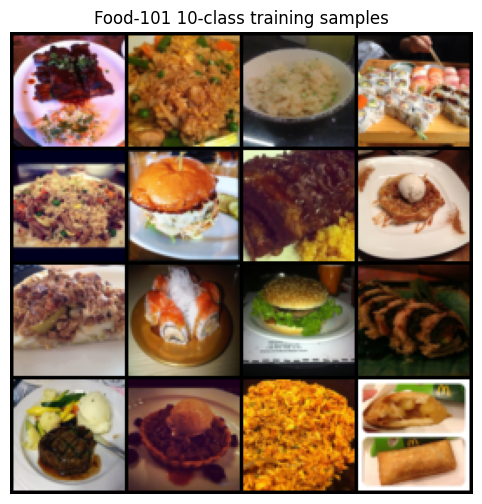

In [14]:
class FilteredFood101Dataset(Dataset):
    def __init__(
        self,
        root: str | Path,
        split: str,
        selected_classes: list[str],
        max_samples_per_class: int | None = None,
        transform=None,
    ):
        self.base_dataset = torchvision.datasets.Food101(
            root=root,
            split=split,
            transform=transform,
            download=True,
        )
        self.selected_classes = selected_classes
        self.class_to_idx = {name: idx for idx, name in enumerate(selected_classes)}
        self.selected_original_ids = {
            self.base_dataset.class_to_idx[class_name] for class_name in selected_classes
        }

        class_counts = Counter()
        self.indices = []

        for idx, original_label_id in enumerate(self.base_dataset._labels):
            if original_label_id not in self.selected_original_ids:
                continue
            class_name = self.base_dataset.classes[original_label_id]
            if max_samples_per_class is not None and class_counts[class_name] >= max_samples_per_class:
                continue
            self.indices.append(idx)
            class_counts[class_name] += 1

        self.samples_per_class = dict(class_counts)

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        base_idx = self.indices[idx]
        image, original_target = self.base_dataset[base_idx]
        class_name = self.base_dataset.classes[original_target]
        remapped_target = self.class_to_idx[class_name]
        return image, remapped_target


transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

train_dataset = FilteredFood101Dataset(
    root=DATA_ROOT,
    split="train",
    selected_classes=SELECTED_FOOD_CLASSES,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    transform=transform,
)

print("selected classes:", SELECTED_FOOD_CLASSES)
print("label mapping:", LABEL_TO_CLASS)
print("samples per class:", train_dataset.samples_per_class)
print("training examples:", len(train_dataset))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

sample_images, sample_labels = next(iter(train_loader))
print("sample batch shape:", sample_images.shape)
print("sample labels:", sample_labels[:8].tolist())
print("sample classes:", [LABEL_TO_CLASS[i] for i in sample_labels[:8].tolist()])
show_tensor_images(sample_images[:16], nrow=4, title="Food-101 10-class training samples")

In [15]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class SimpleVAE(nn.Module):
    def __init__(self, latent_channels: int = LATENT_CHANNELS):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(3, 64, stride=2),
            ConvBlock(64, 128, stride=2),
        )
        self.to_mu = nn.Conv2d(128, latent_channels, kernel_size=1)
        self.to_logvar = nn.Conv2d(128, latent_channels, kernel_size=1)

        self.decoder = nn.Sequential(
            nn.Conv2d(latent_channels, 128, kernel_size=3, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.GroupNorm(8, 32),
            nn.SiLU(),
            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Tanh(),
        )

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = self.encoder(x)
        return self.to_mu(h), self.to_logvar(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


def vae_loss_fn(recon: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    recon_loss = F.l1_loss(recon, x)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    loss = recon_loss + KL_WEIGHT * kl_loss
    return loss, recon_loss, kl_loss


vae = SimpleVAE().to(device)
print("latent shape:", vae.encode(sample_images[:2].to(device))[0].shape)

latent shape: torch.Size([2, 4, 16, 16])


[VAE] epoch 01/15 loss=0.2370 recon=0.2369 kl=1.0578
[VAE] epoch 02/15 loss=0.1435 recon=0.1433 kl=1.4989
[VAE] epoch 03/15 loss=0.1213 recon=0.1212 kl=1.8546
[VAE] epoch 04/15 loss=0.1032 recon=0.1030 kl=2.1923
[VAE] epoch 05/15 loss=0.0921 recon=0.0919 kl=2.5151
[VAE] epoch 06/15 loss=0.0863 recon=0.0860 kl=2.7880
[VAE] epoch 07/15 loss=0.0818 recon=0.0815 kl=3.0275
[VAE] epoch 08/15 loss=0.0782 recon=0.0779 kl=3.2473
[VAE] epoch 09/15 loss=0.0761 recon=0.0758 kl=3.4486
[VAE] epoch 10/15 loss=0.0745 recon=0.0741 kl=3.6194
[VAE] epoch 11/15 loss=0.0722 recon=0.0718 kl=3.7685
[VAE] epoch 12/15 loss=0.0713 recon=0.0709 kl=3.9018
[VAE] epoch 13/15 loss=0.0709 recon=0.0705 kl=4.0188
[VAE] epoch 14/15 loss=0.0705 recon=0.0701 kl=4.1214
[VAE] epoch 15/15 loss=0.0694 recon=0.0689 kl=4.2140


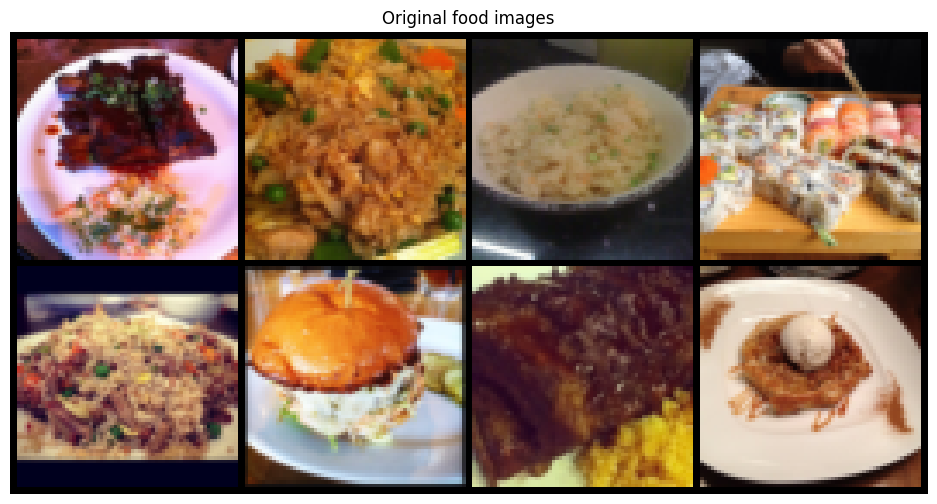

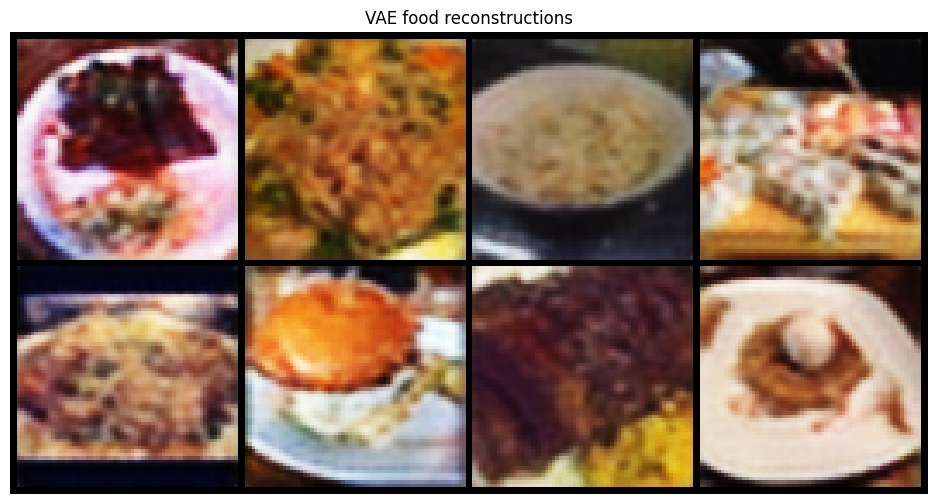

In [16]:
def train_autoencoder(model: nn.Module, loader: DataLoader, epochs: int) -> None:
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_AUTOENCODER)
    model.train()

    for epoch in range(epochs):
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0
        total_items = 0

        for x, _ in loader:
            x = x.to(device)
            recon, mu, logvar = model(x)
            loss, recon_loss, kl_loss = vae_loss_fn(recon, x, mu, logvar)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            total_recon += recon_loss.item() * batch_size
            total_kl += kl_loss.item() * batch_size
            total_items += batch_size

        print(
            f"[VAE] epoch {epoch + 1:02d}/{epochs} "
            f"loss={total_loss / total_items:.4f} "
            f"recon={total_recon / total_items:.4f} "
            f"kl={total_kl / total_items:.4f}"
        )

    torch.save(model.state_dict(), AUTOENCODER_CKPT)


if AUTOENCODER_CKPT.exists():
    vae.load_state_dict(torch.load(AUTOENCODER_CKPT, map_location=device))
    print("Loaded VAE checkpoint from", AUTOENCODER_CKPT)
else:
    train_autoencoder(vae, train_loader, AUTOENCODER_EPOCHS)

vae.eval()

with torch.no_grad():
    batch = sample_images[:8].to(device)
    recon, _, _ = vae(batch)
show_tensor_images(batch, nrow=4, title="Original food images")
show_tensor_images(recon, nrow=4, title="VAE food reconstructions")

In [17]:
class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim: int, scale: float = 30.0):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_proj = x[:, None] * self.W[None, :] * 2 * math.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class Dense(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        self.dense = nn.Linear(input_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dense(x)[..., None, None]


class CrossAttention(nn.Module):
    def __init__(self, embed_dim: int, hidden_dim: int, context_dim: int | None = None):
        super().__init__()
        self.embed_dim = embed_dim
        self.self_attn = context_dim is None
        self.query = nn.Linear(hidden_dim, embed_dim, bias=False)

        if self.self_attn:
            self.key = nn.Linear(hidden_dim, embed_dim, bias=False)
            self.value = nn.Linear(hidden_dim, hidden_dim, bias=False)
        else:
            self.key = nn.Linear(context_dim, embed_dim, bias=False)
            self.value = nn.Linear(context_dim, hidden_dim, bias=False)

    def forward(self, tokens: torch.Tensor, context: torch.Tensor | None = None) -> torch.Tensor:
        query = self.query(tokens)
        if self.self_attn:
            key = self.key(tokens)
            value = self.value(tokens)
        else:
            key = self.key(context)
            value = self.value(context)
        scores = torch.matmul(query, key.transpose(1, 2)) / math.sqrt(self.embed_dim)
        attn = torch.softmax(scores, dim=-1)
        return torch.matmul(attn, value)


class TransformerBlock(nn.Module):
    def __init__(self, hidden_dim: int, context_dim: int):
        super().__init__()
        self.attn_self = CrossAttention(hidden_dim, hidden_dim)
        self.attn_cross = CrossAttention(hidden_dim, hidden_dim, context_dim)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.norm3 = nn.LayerNorm(hidden_dim)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, 3 * hidden_dim),
            nn.GELU(),
            nn.Linear(3 * hidden_dim, hidden_dim),
        )

    def forward(self, x: torch.Tensor, context: torch.Tensor) -> torch.Tensor:
        x = x + self.attn_self(self.norm1(x))
        x = x + self.attn_cross(self.norm2(x), context)
        x = x + self.ffn(self.norm3(x))
        return x


class SpatialTransformer(nn.Module):
    def __init__(self, hidden_dim: int, context_dim: int):
        super().__init__()
        self.transformer = TransformerBlock(hidden_dim, context_dim)

    def forward(self, x: torch.Tensor, context: torch.Tensor) -> torch.Tensor:
        b, c, h, w = x.shape
        residual = x
        x = x.flatten(2).transpose(1, 2)
        x = self.transformer(x, context)
        x = x.transpose(1, 2).reshape(b, c, h, w)
        return x + residual

In [18]:
def marginal_prob_std(t: torch.Tensor | float, sigma: float = SIGMA) -> torch.Tensor:
    if not torch.is_tensor(t):
        t = torch.tensor(t, device=device, dtype=torch.float32)
    else:
        t = t.to(device=device, dtype=torch.float32)
    return torch.sqrt((sigma ** (2 * t) - 1.0) / (2.0 * math.log(sigma)))


def diffusion_coeff(t: torch.Tensor | float, sigma: float = SIGMA) -> torch.Tensor:
    if not torch.is_tensor(t):
        t = torch.tensor(t, device=device, dtype=torch.float32)
    else:
        t = t.to(device=device, dtype=torch.float32)
    return sigma ** t


class LatentUNetTransformer(nn.Module):
    def __init__(
        self,
        marginal_prob_std_fn,
        in_channels: int = LATENT_CHANNELS,
        channels: list[int] | tuple[int, int, int] = (64, 128, 256),
        embed_dim: int = 256,
        context_dim: int = 256,
        n_classes: int = len(SELECTED_FOOD_CLASSES),
    ):
        super().__init__()
        self.marginal_prob_std = marginal_prob_std_fn
        self.act = nn.SiLU()

        self.time_embed = nn.Sequential(
            GaussianFourierProjection(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.SiLU(),
            nn.Linear(embed_dim, embed_dim),
        )
        self.class_embed = nn.Embedding(n_classes, context_dim)

        self.conv1 = nn.Conv2d(in_channels, channels[0], kernel_size=3, padding=1, bias=False)
        self.dense1 = Dense(embed_dim, channels[0])
        self.gnorm1 = nn.GroupNorm(8, channels[0])

        self.conv2 = nn.Conv2d(channels[0], channels[1], kernel_size=3, stride=2, padding=1, bias=False)
        self.dense2 = Dense(embed_dim, channels[1])
        self.gnorm2 = nn.GroupNorm(8, channels[1])
        self.attn2 = SpatialTransformer(channels[1], context_dim)

        self.conv3 = nn.Conv2d(channels[1], channels[2], kernel_size=3, stride=2, padding=1, bias=False)
        self.dense3 = Dense(embed_dim, channels[2])
        self.gnorm3 = nn.GroupNorm(8, channels[2])
        self.attn3 = SpatialTransformer(channels[2], context_dim)

        self.tconv3 = nn.ConvTranspose2d(channels[2], channels[1], kernel_size=4, stride=2, padding=1, bias=False)
        self.dense4 = Dense(embed_dim, channels[1])
        self.tgnorm3 = nn.GroupNorm(8, channels[1])

        self.tconv2 = nn.ConvTranspose2d(channels[1], channels[0], kernel_size=4, stride=2, padding=1, bias=False)
        self.dense5 = Dense(embed_dim, channels[0])
        self.tgnorm2 = nn.GroupNorm(8, channels[0])

        self.out_conv = nn.Conv2d(channels[0], in_channels, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        embed = self.time_embed(t)
        class_context = self.class_embed(y).unsqueeze(1)

        h1 = self.conv1(x) + self.dense1(embed)
        h1 = self.act(self.gnorm1(h1))

        h2 = self.conv2(h1) + self.dense2(embed)
        h2 = self.act(self.gnorm2(h2))
        h2 = self.attn2(h2, class_context)

        h3 = self.conv3(h2) + self.dense3(embed)
        h3 = self.act(self.gnorm3(h3))
        h3 = self.attn3(h3, class_context)

        h = self.tconv3(h3) + self.dense4(embed)
        h = self.act(self.tgnorm3(h))
        h = h + h2

        h = self.tconv2(h) + self.dense5(embed)
        h = self.act(self.tgnorm2(h))
        h = h + h1

        h = self.out_conv(h)
        return h / self.marginal_prob_std(t)[:, None, None, None]


@torch.no_grad()
def encode_latents(x: torch.Tensor) -> torch.Tensor:
    mu, _ = vae.encode(x)
    return mu


score_model = LatentUNetTransformer(marginal_prob_std).to(device)

In [19]:
def loss_fn_cond(model: nn.Module, latents: torch.Tensor, labels: torch.Tensor, marginal_prob_std_fn, eps: float = 1e-5) -> torch.Tensor:
    random_t = torch.rand(latents.shape[0], device=latents.device) * (1.0 - eps) + eps
    noise = torch.randn_like(latents)
    std = marginal_prob_std_fn(random_t)
    perturbed_latents = latents + noise * std[:, None, None, None]
    score = model(perturbed_latents, random_t, labels)
    return torch.mean(torch.sum((score * std[:, None, None, None] + noise) ** 2, dim=(1, 2, 3)))


@torch.no_grad()
def euler_maruyama_sampler(
    score_model: nn.Module,
    marginal_prob_std_fn,
    diffusion_coeff_fn,
    batch_size: int,
    x_shape: tuple[int, int, int],
    num_steps: int = NUM_DIFFUSION_STEPS,
    eps: float = 1e-3,
    y: torch.Tensor | None = None,
) -> torch.Tensor:
    t = torch.ones(batch_size, device=device)
    x = torch.randn(batch_size, *x_shape, device=device) * marginal_prob_std_fn(t)[:, None, None, None]
    time_steps = torch.linspace(1.0, eps, num_steps, device=device)
    step_size = time_steps[0] - time_steps[1]

    for time_step in time_steps:
        batch_time_step = torch.ones(batch_size, device=device) * time_step
        g = diffusion_coeff_fn(batch_time_step)
        mean_x = x + (g ** 2)[:, None, None, None] * score_model(x, batch_time_step, y) * step_size
        x = mean_x + torch.sqrt(step_size) * g[:, None, None, None] * torch.randn_like(x)

    return mean_x

In [20]:
def train_latent_diffusion(model: nn.Module, vae_model: nn.Module, loader: DataLoader, epochs: int) -> None:
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_DIFFUSION)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.98)
    vae_model.eval()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_items = 0

        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            with torch.no_grad():
                latents = encode_latents(x)

            loss = loss_fn_cond(model, latents, y, marginal_prob_std)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            total_items += batch_size

        scheduler.step()
        print(
            f"[LDM] epoch {epoch + 1:02d}/{epochs} "
            f"loss={total_loss / total_items:.4f} "
            f"lr={scheduler.get_last_lr()[0]:.2e}"
        )

    torch.save(model.state_dict(), DIFFUSION_CKPT)


if DIFFUSION_CKPT.exists():
    score_model.load_state_dict(torch.load(DIFFUSION_CKPT, map_location=device))
    print("Loaded diffusion checkpoint from", DIFFUSION_CKPT)
else:
    train_latent_diffusion(score_model, vae, train_loader, DIFFUSION_EPOCHS)

score_model.eval()

[LDM] epoch 01/40 loss=596.7848 lr=1.96e-04
[LDM] epoch 02/40 loss=317.4571 lr=1.92e-04
[LDM] epoch 03/40 loss=276.2153 lr=1.88e-04
[LDM] epoch 04/40 loss=263.8562 lr=1.84e-04
[LDM] epoch 05/40 loss=261.5144 lr=1.81e-04
[LDM] epoch 06/40 loss=253.5182 lr=1.77e-04
[LDM] epoch 07/40 loss=246.8978 lr=1.74e-04
[LDM] epoch 08/40 loss=242.9874 lr=1.70e-04
[LDM] epoch 09/40 loss=239.5812 lr=1.67e-04
[LDM] epoch 10/40 loss=235.4779 lr=1.63e-04
[LDM] epoch 11/40 loss=230.3673 lr=1.60e-04
[LDM] epoch 12/40 loss=229.7774 lr=1.57e-04
[LDM] epoch 13/40 loss=229.2006 lr=1.54e-04
[LDM] epoch 14/40 loss=220.2707 lr=1.51e-04
[LDM] epoch 15/40 loss=231.8037 lr=1.48e-04
[LDM] epoch 16/40 loss=234.5739 lr=1.45e-04
[LDM] epoch 17/40 loss=224.3627 lr=1.42e-04
[LDM] epoch 18/40 loss=218.0006 lr=1.39e-04
[LDM] epoch 19/40 loss=218.8707 lr=1.36e-04
[LDM] epoch 20/40 loss=214.6748 lr=1.34e-04
[LDM] epoch 21/40 loss=215.1616 lr=1.31e-04
[LDM] epoch 22/40 loss=212.0604 lr=1.28e-04
[LDM] epoch 23/40 loss=217.2580 

LatentUNetTransformer(
  (act): SiLU()
  (time_embed): Sequential(
    (0): GaussianFourierProjection()
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): SiLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
  )
  (class_embed): Embedding(10, 256)
  (conv1): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (dense1): Dense(
    (dense): Linear(in_features=256, out_features=64, bias=True)
  )
  (gnorm1): GroupNorm(8, 64, eps=1e-05, affine=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (dense2): Dense(
    (dense): Linear(in_features=256, out_features=128, bias=True)
  )
  (gnorm2): GroupNorm(8, 128, eps=1e-05, affine=True)
  (attn2): SpatialTransformer(
    (transformer): TransformerBlock(
      (attn_self): CrossAttention(
        (query): Linear(in_features=128, out_features=128, bias=False)
        (key): Linear(in_features=128, out_features=128, bias=False)
        (va

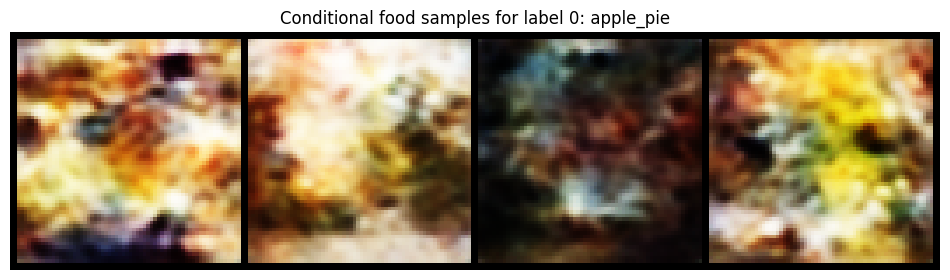

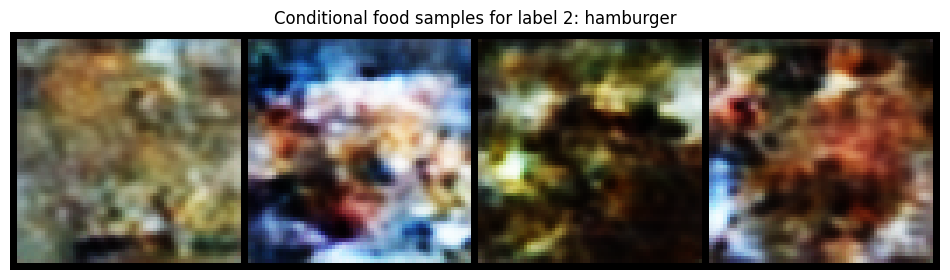

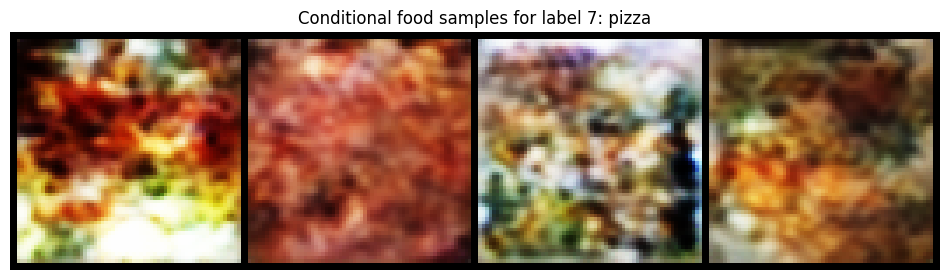

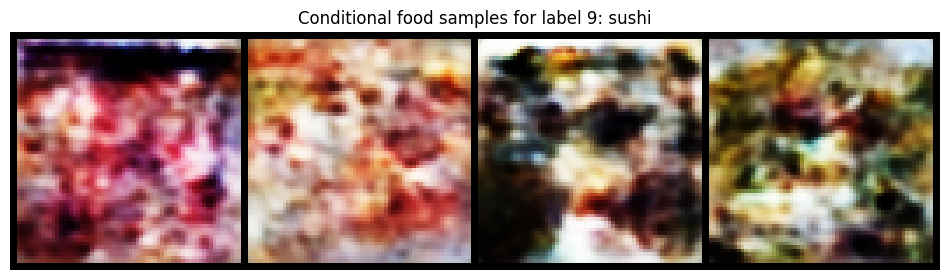

In [21]:
@torch.no_grad()
def sample_class(model: nn.Module, vae_model: nn.Module, class_id: int, n_samples: int = 4) -> torch.Tensor:
    labels = torch.full((n_samples,), class_id, device=device, dtype=torch.long)
    latent_samples = euler_maruyama_sampler(
        score_model=model,
        marginal_prob_std_fn=marginal_prob_std,
        diffusion_coeff_fn=diffusion_coeff,
        batch_size=n_samples,
        x_shape=(LATENT_CHANNELS, LATENT_SIZE, LATENT_SIZE),
        y=labels,
    )
    return vae_model.decode(latent_samples)


target_labels = [0, 2, 7, 9]

for class_id in target_labels:
    class_name = LABEL_TO_CLASS[class_id]
    samples = sample_class(score_model, vae, class_id=class_id, n_samples=4)
    show_tensor_images(samples, nrow=4, title=f"Conditional food samples for label {class_id}: {class_name}")